# TNMH mixing times — the numerical analysis, recomputed from scratch

*Joaquín G. Márquez Olguín - ICFO  
Companion docs: [README](../../README.md), [THEORY](../../THEORY.md).*

## How the code is organized

- **`main.jl`** — the core engine. Builds the Ising partition function as a `D=2` PEPS
  (`create_ising_peps`), contracts it row-by-row with a **boundary MPS** truncated to bond
  `D_bound` to get an approximate sampler `q` (`sample_config_opt`), and runs the
  Independence-Metropolis–Hastings chain (`run_mcmc_sweep`). The boundary MPS is the key
  trick: instead of contracting the full 2D network (exponential), we sweep one row at a
  time, applying each row as an MPO and re-compressing to bond `D_bound` — turning a 2D
  problem into a sequence of cheap 1D ones.

- **`tools/tnmh_tools.jl`** — the analysis layer. Brute-force oracles
  (`enumerate_weights`), the IMH transition matrix + spectrum (`imh_kernel`, `lambda2`,
  `tv_decay`), the per-layer rate (`compute_rho_plateau`), typical-case diagnostics
  (`weight_samples`, `chi2_sampled`, `integrated_autocorr`), validation
  (`cftp_coalescence`, `glauber_tau_int`), and the analytical primitives
  (`accumulation_curve`, `perrow_weights`).

**`main.jl` produces samples / probabilities; `tnmh_tools.jl`
measures things about them.**

In [ ]:
using Plots, JLD2, Statistics, LinearAlgebra, Printf, ITensors, ITensorMPS

include("main.jl"); include("tools/tnmh_tools.jl")

betac = log(1 + sqrt(2)) / 2          # critical inverse temperature β_c ≈ 0.4407

set_seed(2024)

gr(size=(720,440), legendfontsize=9, guidefontsize=11, titlefontsize=12)
println("ready — β_c = ", round(betac, digits=6))

ready — β_c = 0.440687


## 0. Is the proposal a valid distribution?

Before measuring anything, confirm the two non-negotiable controls: 

(i) the proposal probabilities sum to 1, and 

(ii) at *exact* bond dimension (`D = 2^{Ly}`) the proposal equals the true Boltzmann `π`, so `C = max π/q = 1`.

**How the code does it.** `enumerate_weights` loops over **all `2^N` configurations**
(`N = Lx·Ly`). For each it calls `proposal_logprob` — the *deterministic* version of the
sampler that, instead of drawing spins, pins them to the given config and accumulates the
chain-rule log-probability — and `measure_energy` for the exact Boltzmann weight. It returns
`logq, logπ, logw=logπ−logq`, and `C = max_x exp(logw)`. Cost is `O(2^N ×` one contraction`)`,
so keep `N ≲ 20`.

**Parameters:** `Lx, Ly, β` and the two bond dimensions.

In [ ]:
Lx, Ly, β = 3, 4, betac
D_trunc  = 2                      # working bond dimension
D_exact  = 2^Ly                   # lossless bond dimension

r_trunc = enumerate_weights(Lx, Ly, β, D_trunc)
r_exact = enumerate_weights(Lx, Ly, β, D_exact)
@printf("Σq (truncated) = %.12f      (must be 1)\n", sum(exp.(r_trunc.logq)))
@printf("C at D=%d        = %.8f      (truncation bites ⇒ C>1)\n", D_trunc, r_trunc.C)
@printf("C at exact D=%d  = %.8f      (q = π exactly ⇒ C=1)\n", D_exact, r_exact.C)

Σq (truncated) = 1.000000000000      (must be 1)
C at D=2        = 1.00128585      (truncation bites ⇒ C>1)
C at exact D=16  = 1.00000000      (q = π exactly ⇒ C=1)


## 1. `C` *is* the relaxation time (Liu's identity)

For an Independence-MH chain, Liu (1996) proved the second eigenvalue of the
transition matrix is *exactly* `λ₂ = 1 − 1/C`. So `C` isn't a bound on the mixing time — it
**is** it. We verify this by building the full kernel and diagonalizing it, and we check that
the total-variation distance decays as `(1−1/C)^n`.

**How the code does it.** `imh_kernel(logq, logw)` assembles the `2^N × 2^N` transition
matrix from the IMH acceptance rule `min(1, w(x')/w(x))` weighted by the proposal `q(x')`;
`lambda2` returns its second-largest eigenvalue; `tv_decay` iterates the kernel from the
worst-case starting state and measures `‖P^n − π‖_TV`. Building a dense `2^N × 2^N` matrix is
the bottleneck — this is a *small-lattice* check (the `3×4` cases below are `4096×4096`).

**Parameters:** the list of `(Lx, Ly, D)` cases.

max |λ₂ − (1−1/C)| = 4.4e-14


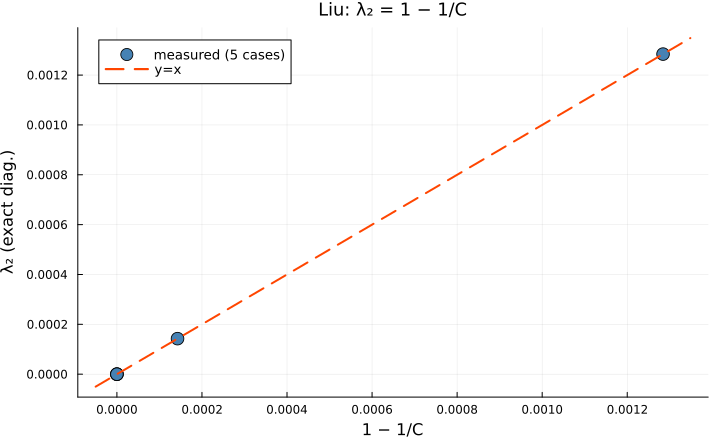

In [ ]:
cases = [(3,4,2), (3,4,3), (2,5,2), (2,6,2), (4,3,2)] 
pred = Float64[]; meas = Float64[]

for (lx,ly,D) in cases
    r = enumerate_weights(lx,ly,betac,D)
    push!(pred, 1 - 1/r.C)
    push!(meas, lambda2(imh_kernel(r.logq, r.logw)))
end

@printf("max |λ₂ − (1−1/C)| = %.1e\n", maximum(abs.(meas .- pred)))

p = scatter(pred, meas, ms=7, color=:steelblue, label="measured ($(length(cases)) cases)",
            xlabel="1 − 1/C", ylabel="λ₂ (exact diag.)", title="Liu: λ₂ = 1 − 1/C")
lo = -5e-5
hi = maximum(pred)*1.05
plot!(p,[lo,hi],[lo,hi],ls=:dash,lw=2,color=:orangered,label="y=x"); p

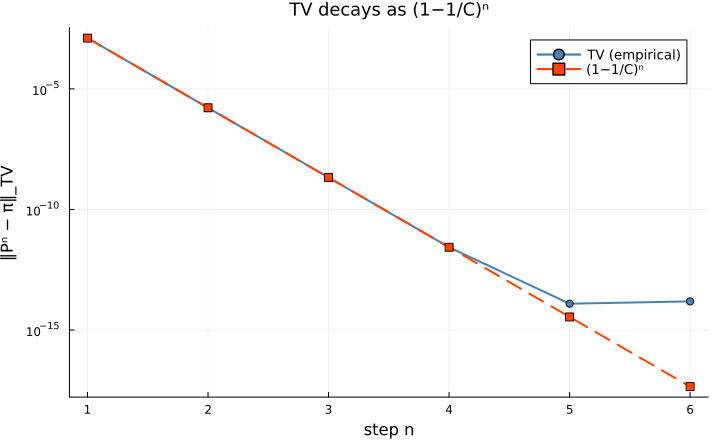

In [ ]:
# TV decay from the worst-case start (3×4, D=2): empirical vs the (1−1/C)^n bound
r = enumerate_weights(3,4,betac,2)
P = imh_kernel(r.logq, r.logw)
tv = tv_decay(P, exp.(r.logpi), r.argmax, 6)
bound = [(1 - 1/r.C)^n for n in 1:6]

plot(1:6, tv, marker=:circle, lw=2, yscale=:log10, label="TV (empirical)", color=:steelblue,
     xlabel="step n", ylabel="‖Pⁿ − π‖_TV", title="TV decays as (1−1/C)ⁿ")
plot!(1:6, bound, marker=:square, lw=2, ls=:dash, label="(1−1/C)ⁿ", color=:orangered)

Note that the empirial results hit the Machine Precision around 1e-15, but matches the expected behaviour.

## 2. Worst case: `C ~ ρ^{Lx}` and the per-row rate `ρ(Ly, D, β)`

Because the proposal samples row by row, the worst-case weight *multiplies*
across the `Lx` rows: `C ~ ρ^{Lx}`. We confirm (left) `log C` is linear in `Lx`, and (right)
the per-row rate `ρ` rises with strip width `Ly` but is crushed by larger `D`.

**How the code does it.** *Left:* `enumerate_weights` gives the exact `C` at growing `Lx`;
the slope of `log C` is `log ρ`. *Right:* `compute_rho_plateau` runs **two** boundary MPS up
the strip in parallel — one exact (bond `2^{Ly}`), one truncated (bond `D`) — and at the
saturated top row maximizes the ratio of their single-row marginals over all `2^{Ly}` row
configs. That maximum is `ρ`.

**Parameters:** `Lx_list` (enumeration), and `Lys × Ds` for the rate.

slope = log ρ_eff = 0.0018  ⇒  ρ_eff = 1.00178


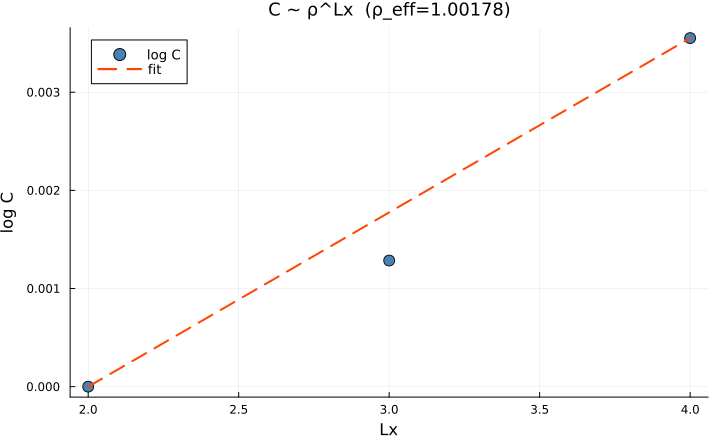

In [ ]:
# Left: log C vs Lx  (enumeration — keep Lx ≤ 4 for speed; Lx=5 is ~2^20 configs)
Lx_list = [2,3,4]

logC = [log(enumerate_weights(lx,4,betac,2).C) for lx in Lx_list]
slope = (logC[end]-logC[1])/(Lx_list[end]-Lx_list[1])

@printf("slope = log ρ_eff = %.4f  ⇒  ρ_eff = %.5f\n", slope, exp(slope))

pL = scatter(Lx_list, logC, ms=6, color=:steelblue, label="log C", xlabel="Lx", ylabel="log C",
             title="C ~ ρ^Lx  (ρ_eff=$(round(exp(slope),digits=5)))", legend=:topleft)
plot!(pL, Lx_list, logC[1].+slope.*(Lx_list.-Lx_list[1]), ls=:dash, lw=2, color=:orangered, label="fit")
pL

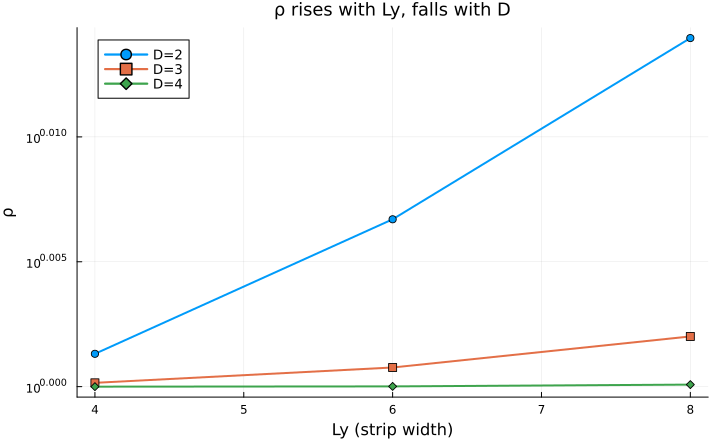

In [ ]:
# Right: ρ vs Ly for several D 
Lys = [4,6,8]
Ds = [2,3,4]
Lx_env = 16

ρ = Dict(D => [compute_rho_plateau(Lx_env, ly, betac, D) for ly in Lys] for D in Ds)
pR = plot(xlabel="Ly (strip width)", ylabel="ρ", yscale=:log10, title="ρ rises with Ly, falls with D", legend=:topleft)

for (mk,D) in zip([:circle,:square,:diamond], Ds)
    plot!(pR, Lys, ρ[D], marker=mk, lw=2, label="D=$D")
end
pR

### 2b. How ρ depends on temperature β

We want to see whether ρ peaks at β_c or behaves differently. This matters for the
analytical program: does "criticality ⇒ hard truncation" map to a peak in ρ?

**Finding (spoiler).** ρ rises **monotonically** with β — it does *not* peak at β_c. The
critical point is where the *Ly-scaling* changes (log ρ ∝ Ly), not where the absolute ρ
is largest. Deep in the ordered phase, the boundary entanglement saturates to log 2 (a
cat state), so ε_D and ρ eventually plateau too.

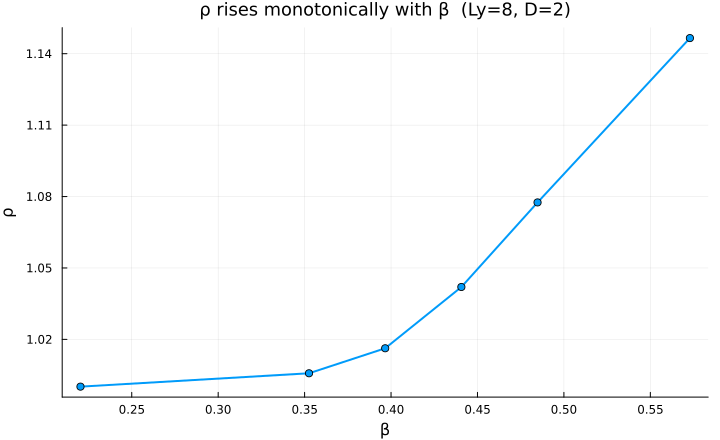

In [ ]:
# ρ vs β at fixed Ly, D  (compute_rho_plateau at each temperature)
Ly_rho, D_rho, Lx_rho = 8, 2, 40
betas_rho = betac .* [0.5, 0.8, 0.9, 1.0, 1.1, 1.3]

rho_beta = [compute_rho_plateau(Lx_rho, Ly_rho, b, D_rho) for b in betas_rho]
plot(betas_rho, rho_beta, marker=:circle, lw=2, legend=false,
     xlabel="β", ylabel="ρ", title="ρ rises monotonically with β  (Ly=$Ly_rho, D=$D_rho)")

### 2c. The additive→multiplicative bridge: ρ − 1 tracks ε_D

The truncation gives an *additive* error ε_D (how far apart the exact and
truncated boundary environments are). Mixing needs a *multiplicative* bound (ρ). Here we
check whether ρ − 1 is controlled by ε_D — the bridge between the two.

**How ε_D is computed.** `truncation_error_fidelity` builds the saturated boundary MPS
at exact bond `2^Ly` and at truncated bond `D`, takes their fidelity
`F = |⟨e|e_D⟩|/(‖e‖‖e_D‖)`, and returns `ε_D = √(1−F²)` — the sine of the angle between
the two converged environments. This is a *distance* (additive), not a ratio (multiplicative).

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

  D  |   ε_D       |   ρ − 1
  2  |  2.2003e-02  |  4.2003e-02
  3  |  6.9811e-03  |  5.7276e-03
  4  |  1.4674e-04  |  1.8857e-04
  6  |  0.0000e+00  |  1.9464e-06


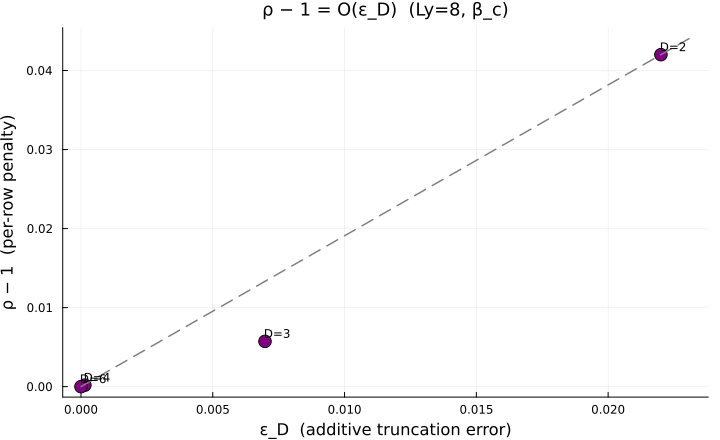

In [ ]:
# ε_D vs ρ − 1 at fixed Ly, β_c, sweeping D
Lx_eps, Ly_eps = 40, 8                
Ds_eps = [2, 3, 4, 6]

epsD = [truncation_error_fidelity(Lx_eps, Ly_eps, betac, D) for D in Ds_eps]
rhoD = [compute_rho_plateau(Lx_eps, Ly_eps, betac, D) for D in Ds_eps]

println("  D  |   ε_D       |   ρ − 1")
for (D,e,r) in zip(Ds_eps, epsD, rhoD)
    @printf("  %d  |  %.4e  |  %.4e\n", D, e, r-1)
end

p = scatter(epsD, rhoD .- 1, ms=7, color=:purple, legend=false,
            xlabel="ε_D  (additive truncation error)", ylabel="ρ − 1  (per-row penalty)",
            title="ρ − 1 = O(ε_D)  (Ly=$Ly_eps, β_c)")
for (i,D) in enumerate(Ds_eps)
    annotate!(p, epsD[i], rhoD[i]-1+0.001, text("D=$D",8,:left))
end

xs = range(0, maximum(epsD)*1.05, length=2)
plot!(p, xs, (rhoD[1]-1)/epsD[1] .* xs, ls=:dash, lw=1.5, color=:gray); p

### 2d. Marginal ≈ conditional: the [1,1] cap is harmless

`compute_rho_plateau` measures ρ by closing the row's upper bond with a
`[1,1]` vector, which *marginalises* over everything above (it sums both spin values).
But the chain-rule object that enters the importance weight is the *conditional* ratio
(pinning the spins above to their sampled values). Are these the same?

**How we check.** The conditional ρ is extracted from the slope of `log C` vs `Lx`
(§2a: `ρ_eff`). The marginal ρ is `compute_rho_plateau`. If they agree, the tracker
measures the right object. At small `(Ly, D)` they match to ~0.1%.

In [ ]:
# Marginal ρ (plateau tracker) vs conditional ρ_eff (slope of log C)
Ly_mc, D_mc = 4, 2        

rho_marg = compute_rho_plateau(40, Ly_mc, betac, D_mc)
rho_eff_val = exp(slope)

@printf("ρ_marginal  (plateau, [1,1] cap)      = %.6f\n", rho_marg)
@printf("ρ_eff       (slope of log C, conditional) = %.6f\n", rho_eff_val)
@printf("ratio ρ_eff / ρ_marg                      = %.4f   (≈1 ⇒ harmless)\n", rho_eff_val / rho_marg)

ρ_marginal  (plateau, [1,1] cap)      = 1.003210
ρ_eff       (slope of log C, conditional) = 1.001777
ratio ρ_eff / ρ_marg                      = 0.9986   (≈1 ⇒ harmless)


### 2e. Bond-dimension verdict: how large must D be?

For each strip width Ly, find (i) `D*` = the smallest D that keeps
`ρ ≤ 1 + 1/Lx` (so C stays O(1) for a strip of length Lx), and (ii) `D(ρ=1)` = the D
at which the proposal becomes exact. The practical message: D = 2–3 suffices at Ly ≤ 8;
exact requires D ~ 2^(Ly/2).

In [ ]:
# D* and D(ρ=1) for several Ly  (sweeps D from 2 to 2^Ly — slow at Ly=8)
Lx_Ds = 40                        
Lys_Ds = [4, 6, 8]  

thresh = 1 + 1/Lx_Ds

println("Ly   D*(ρ≤$(round(thresh,digits=4)))   D(ρ=1)")
for Ly in Lys_Ds
    Dstar = -1; Dexact = -1
    for D in 2:(2^Ly)
        r = compute_rho_plateau(Lx_Ds, Ly, betac, D)
        if Dstar == -1 && r <= thresh; Dstar = D; end
        if abs(r - 1.0) < 1e-6; Dexact = D; break; end
    end
    @printf("%2d    %3s               %3s\n", Ly,
            Dstar > 0 ? string(Dstar) : "—", Dexact > 0 ? string(Dexact) : "—")
end

Ly   D*(ρ≤1.025)   D(ρ=1)
 4      2                 4
 6      2                 —
 8      3                 —


## 3. Why it's fast in practice — the typical case

The worst case is exponential, yet acceptance rates are high. Resolution: the
worst case is an *exponentially rare* config. We show the typical weight is `≈1`, the
χ²-divergence grows far slower than `C`, and the chain autocorrelation time is `τ_int ≈ 0.5`
(independent samples).

**How the code does it.** `weight_samples` draws independent configs straight from `q`
(`sample_config_opt`) and records `log w`; `chi2_sampled` estimates `E_q[w²]−1`. The *exact*
χ² is `Σ_x π(x)²/q(x) − 1`, read off `enumerate_weights`. For the chain's `τ_int` we run the
actual IMH loop (below — propose a fresh config, accept with the MH rule) and feed the energy
series to `integrated_autocorr`.

**Parameters:** sample sizes, lattice sizes, chain length.

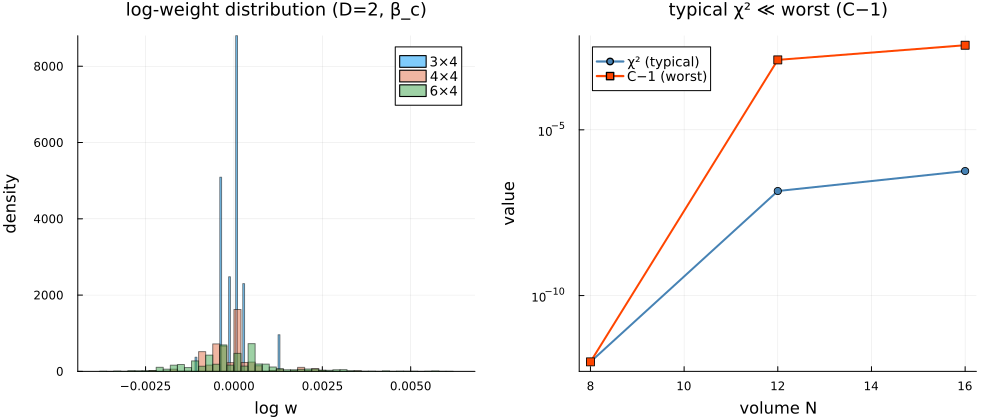

In [ ]:
# Weight distribution (independent draws from q) + exact χ² vs worst case C−1
sizes = [(3,4),(4,4),(6,4)]
nsamp = 2000 

ph = plot(title="log-weight distribution (D=2, β_c)", xlabel="log w", ylabel="density")
for (lx,ly) in sizes
    ws = weight_samples(lx,ly,betac,2,nsamp); histogram!(ph, ws.logw, bins=45, alpha=0.5, normalize=true, label="$(lx)×$(ly)")
end

vols = [8,12,16]
Cm1=Float64[]; chi2=Float64[]

for (lx,ly) in [(2,4),(3,4),(4,4)]
    r = enumerate_weights(lx,ly,betac,2); push!(Cm1, r.C-1); push!(chi2, sum(exp.(2 .* r.logpi .- r.logq))-1)
end

pc = plot(vols, max.(chi2,1e-12), marker=:circle, lw=2, yscale=:log10, color=:steelblue, label="χ² (typical)",
          xlabel="volume N", ylabel="value", title="typical χ² ≪ worst (C−1)", legend=:topleft)
plot!(pc, vols, max.(Cm1,1e-12), marker=:square, lw=2, color=:orangered, label="C−1 (worst)")
plot(ph, pc, layout=(1,2), size=(1000,420), margin=4Plots.mm)

In [ ]:
# τ_int of the actual TNMH chain (run the IMH loop and measure autocorrelation)
function tnmh_energy_series(Lx,Ly,beta,D,N)
    cfg,clq = sample_config_opt(Lx,Ly,beta,D)
    cE = measure_energy(cfg)
    Es = zeros(N)

    for i in 1:N
        nc,nlq = sample_config_opt(Lx,Ly,beta,D)
        nE = measure_energy(nc)
        if log(rand()) < (clq - nlq) - beta*(nE - cE)   # IMH acceptance: min(1, w(x')/w(x))
            clq = nlq; cE = nE
        end
        Es[i] = cE
    end
    Es
end

for L in (4,6,8)
    @printf("L=%d :  τ_int(TNMH) = %.2f   (0.5 = independent samples)\n", L,
            integrated_autocorr(tnmh_energy_series(L,L,betac,2,2000)))
end

L=4 :  τ_int(TNMH) = 0.53   (0.5 = independent samples)
L=6 :  τ_int(TNMH) = 0.53   (0.5 = independent samples)
L=8 :  τ_int(TNMH) = 0.48   (0.5 = independent samples)


### 3b. Restricted C_S: remove the rare tail and C collapses

If the worst-case config is rare, then restricting the `max` in
`C = max_x π/q` to a high-probability set S (removing the tails) should give a much smaller
`C_S ≪ C`. This is the "warm-start" / typical-set mixing picture.

**How the code does it.** We enumerate all configs, sort by log w, and compute
`C_S = max_{x ∈ S} w(x)` where S excludes the top fraction by energy. At small lattices
(4×4, C ≈ 1.004), the worst config is *not yet* an outlier — C_S ≈ C even at the narrowest
band. The divergence between C and C_S requires larger volumes where C >> 1.

In [ ]:
# Restricted C_S: remove the top-f fraction of configs by w, recompute max w over the rest
Lx_cs, Ly_cs, D_cs = 4, 4, 2
r = enumerate_weights(Lx_cs, Ly_cs, betac, D_cs)
w = exp.(r.logw); q = exp.(r.logq)
fracs = [0.0, 0.001, 0.01, 0.05, 0.10] 

println("  excluded  |  C_S           |  C_S / C")
for f in fracs
    sorted_idx = sortperm(w, rev=true)
    n_exclude = max(0, Int(ceil(f * length(w))))
    keep = sorted_idx[n_exclude+1:end]
    CS = maximum(w[keep])
    @printf("  %.1f%%     |  %.6f     |  %.4f\n", f*100, CS, CS/r.C)
end
@printf("\nC = %.6f   (all configs included)\n", r.C)

  excluded  |  C_S           |  C_S / C
  0.0%     |  1.003558     |  1.0000
  0.1%     |  1.003558     |  1.0000
  1.0%     |  1.003558     |  1.0000
  5.0%     |  1.002352     |  0.9988
  10.0%     |  1.001928     |  0.9984

C = 1.003558   (all configs included)


### 3c. The acceptance dip at larger L (from the original sweep)

At L ≤ 8 the chain is essentially iid. But the original phase-transition sweep
(stored in `ising_mcmc_results_D2.jld2`, computed in `TNMH_test.ipynb`) shows that at
L = 32–64, the acceptance rate dips to 18–62% near β_c. This is where the exponential
worst case starts to bite in practice.

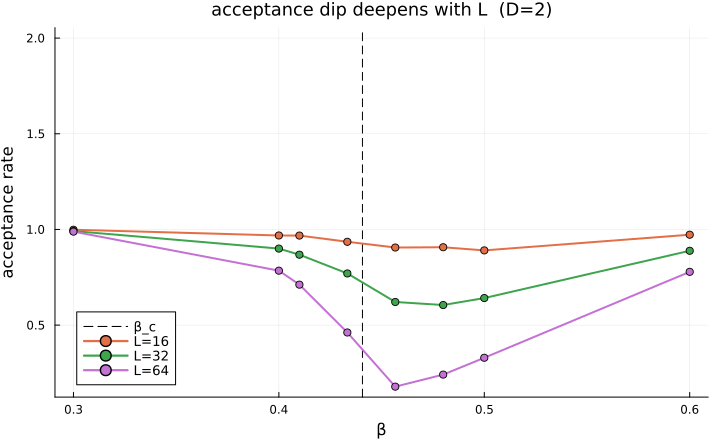

In [ ]:
# Reload the large-L sweep (the data is in ising_mcmc_results_D2.jld2)
d = jldopen("ising_mcmc_results_D2.jld2","r")
Lvals = d["L_values"]
bvals = d["beta_values"]
racc = d["results_acc"]
close(d)

p = plot(xlabel="β", ylabel="acceptance rate", title="acceptance dip deepens with L  (D=2)", legend=:bottomleft)
vline!(p, [betac], ls=:dash, color=:black, label="β_c")
for L in Lvals
    plot!(p, bvals, racc[L], marker=:circle, lw=2, label="L=$L")
end
p

## 4. Independent validation — CFTP and Glauber

We re-derive `C` by a completely different route (coupling-from-the-past), and
measure the collective-update speedup vs single-spin Glauber dynamics.

**How the code does it.** `cftp_coalescence` uses the IMH fact that all coupled chains
coalesce the first time the worst config `s★` is *proposed* — a geometric event with success
probability `q(s★)` — so the mean coalescence time should equal `1/q(s★) = C/π(s★)`. It finds
`s★` via `enumerate_weights`, then simulates the geometric waiting time. `glauber_tau_int`
runs ordinary single-spin Metropolis and measures its `τ_int` for comparison.

**Parameters:** CFTP geometry + trial count (**⏱ wait ≈ `1/q(s★)` per trial** — use a
geometry where `s★` isn't too rare); Glauber size + steps.

CFTP (2×5): empirical 15690 vs predicted 1/q(s★) 14854 → ratio 1.056
L=8, β_c:  τ_int TNMH 0.48 vs Glauber 4.39 → 9.2× per sweep


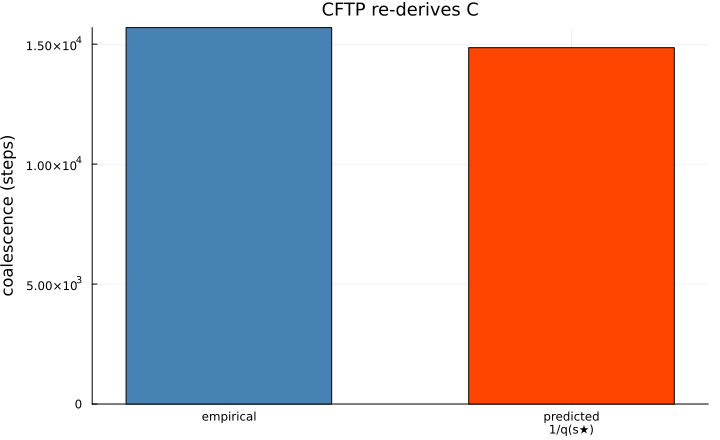

In [ ]:
# CFTP: 2×5,D=2 is feasible (q(s★) not too small); 3×4 would need ~63 h (s★ too rare)
cf = cftp_coalescence(2, 5, betac, 2; ntrials=20)
@printf("CFTP (2×5): empirical %.0f vs predicted 1/q(s★) %.0f → ratio %.3f\n",
        cf.mean_time, cf.predicted, cf.mean_time/cf.predicted)

# Speedup: TNMH vs Glauber τ_int at L=8
τ_tnmh = integrated_autocorr(tnmh_energy_series(8,8,betac,2,2000))
τ_glab = glauber_tau_int(8,8,betac,3000).tau_int  
@printf("L=8, β_c:  τ_int TNMH %.2f vs Glauber %.2f → %.1f× per sweep\n", τ_tnmh, τ_glab, τ_glab/τ_tnmh)

bar(["empirical","predicted\n1/q(s★)"], [cf.mean_time, cf.predicted], color=[:steelblue,:orangered],
    legend=false, ylabel="coalescence (steps)", title="CFTP re-derives C", bar_width=0.6)

## 5. The accumulation view — `log C = Σ_x δ_x`

Reframe `C ~ ρ^{Lx}` as an *accumulation*: `log C` is a sum of per-row
contributions `δ_x`. Watching that sum grow row by row is watching the mixing-time constant
build up. The worst config climbs to `log C`; typical configs stay flat near 0.

**How the code does it.** `accumulation_curve` runs the pinned proposal **twice** for a fixed
config — once truncated (`D`), once exact (`2^{Ly}`, where `q = π`) — and subtracts the
*running* row-by-row log-probabilities, giving `δ_x` and the running ratio `log r_k`. The
endpoint equals `log w(config)`, and for `s★` equals `log C`.

**Parameters:** geometry, `D`, the worst vs typical configs.

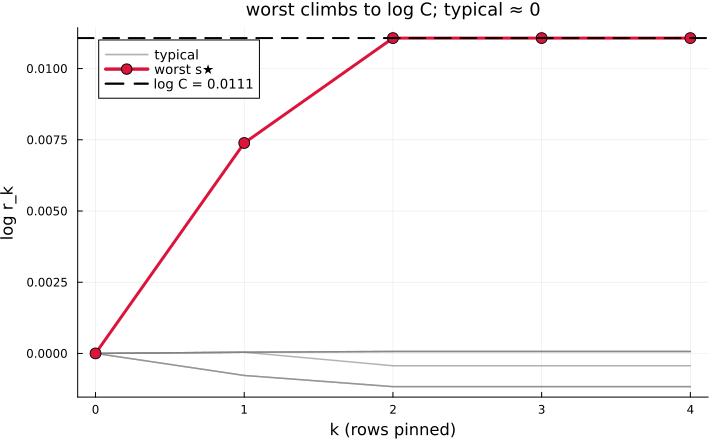

In [ ]:
Lx, Ly, β, D = 4, 4, 0.60, 2    
r = enumerate_weights(Lx,Ly,β,D)
sstar = config_from_int(r.argmax-1,Lx,Ly)
curve_star = vcat(0.0, accumulation_curve(sstar,Lx,Ly,β,D))
typ = [vcat(0.0, accumulation_curve(sample_config_opt(Lx,Ly,β,D)[1],Lx,Ly,β,D)) for _ in 1:6]

ks = 0:Lx
p = plot(xlabel="k (rows pinned)", ylabel="log r_k", title="worst climbs to log C; typical ≈ 0", legend=:topleft)
for (j,c) in enumerate(typ)
    plot!(p, ks, c, lw=1.5, color=:gray, alpha=0.6, label=(j==1 ? "typical" : ""))
end
plot!(p, ks, curve_star, lw=3, marker=:circle, ms=6, color=:crimson, label="worst s★")
hline!(p, [log(r.C)], ls=:dash, lw=2, color=:black, label="log C = $(round(log(r.C),digits=4))"); p

## 6. The analytical result — `ρ − 1 = ` the *spread* of `g`

We confirm the per-row closed form `r(s) = E_p[g]/g(s)` (with `g(s)` the relative
truncation effect on config `s`): the mixing penalty is the **variation** of the truncation
across configs, not its size. Then connect `ρ−1` to the boundary entanglement.

**How the code does it.** `perrow_weights` returns the exact and truncated single-row weights
`a(s), a_D(s)` for every config at the saturated top row; from these `g = a_D/a`,
`p = a/Σa`, and `ρ = E_p[g]/min g`. For the entanglement we build the saturated environment
densely and SVD it across the central cut (`boundary_schmidt` below) — the Schmidt spectrum
gives the entropy `S` and the truncation error `ε_D`.

**Parameters:** the `(Ly, D, β)` grid for the spread; the `β` range for the gap.

30 points;  median |ρ−1 − spread|/(ρ−1) = 0.003


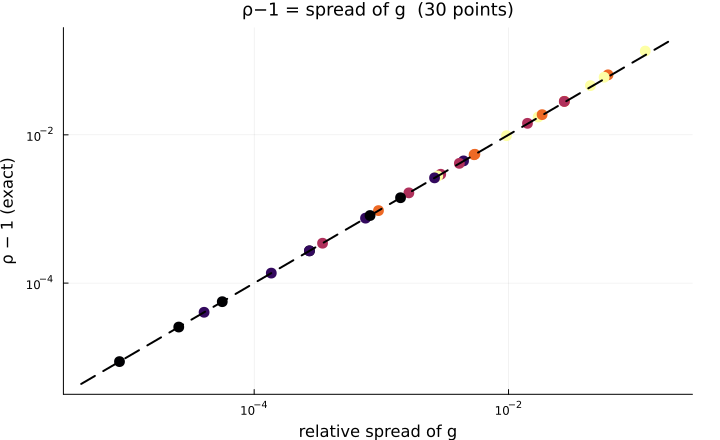

In [ ]:
# (a) ρ − 1 equals the relative spread of g, across regimes
Lys=[4, 6, 8]
Ds=[2, 3]
betas=[0.30, 0.35, betac, 0.50, 0.60]
Lx_env=16  

ρm1=Float64[]; spread=Float64[]; bvals_sp=Float64[]

for ly in Lys, D in Ds, β in betas
    pe, pt = perrow_weights(Lx_env,ly,β,D)
    g=pt./pe
    pp=pe./sum(pe)
    Eg=sum(pp.*g)
    mg=minimum(g)

    push!(ρm1, Eg/mg - 1); push!(spread, (Eg-mg)/Eg); push!(bvals_sp, β)
end

m = ρm1 .> 1e-9
@printf("%d points;  median |ρ−1 − spread|/(ρ−1) = %.3f\n", sum(m), median(abs.(ρm1[m].-spread[m])./ρm1[m]))

ps = scatter(spread[m], ρm1[m], zcolor=bvals_sp[m], ms=6, markerstrokewidth=0, xscale=:log10, yscale=:log10,
             colorbar_title="β", xlabel="relative spread of g", ylabel="ρ − 1 (exact)",
             title="ρ−1 = spread of g  ($(sum(m)) points)", legend=false)
lo,hi=minimum(ρm1[m])*0.5,maximum(ρm1)*1.5; plot!(ps,[lo,hi],[lo,hi],ls=:dash,lw=2,color=:black)
ps

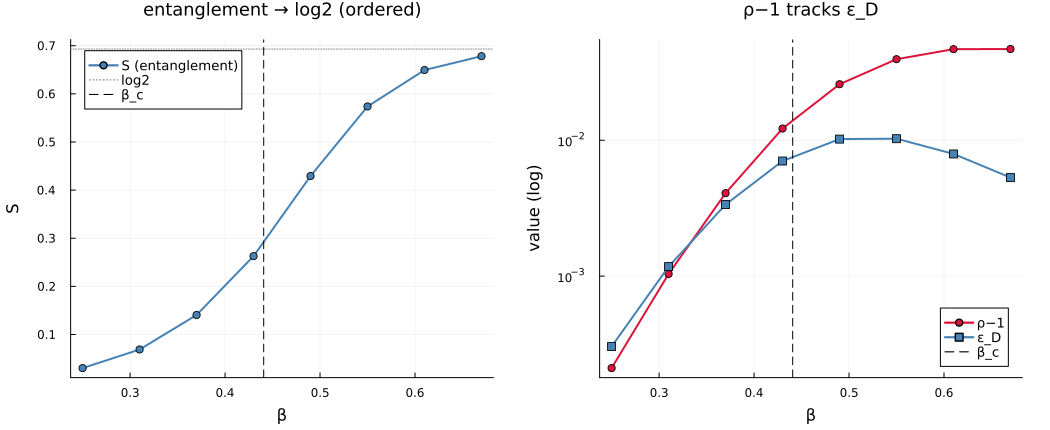

In [ ]:
# (b) entanglement spectrum vs β: S, ε_D, and ρ−1 (built by densifying the environment + SVD)
function boundary_schmidt(Lx,Ly,beta)
    A, s, v = create_ising_peps(Lx,Ly,beta)
    b = [Index(2,"Site,b=$y") for y in 1:Ly]

    Ee = MPS([replaceinds(A[Lx,y]*ITensor([1.0,1.0],s[Lx,y]),[v[Lx-1,y]]=>[b[y]]) for y in 1:Ly])
    for x in Lx-1:-1:2
        tm=[replaceinds(A[x,y]*ITensor([1.0,1.0], s[x,y]), [v[x,y], v[x-1,y]]=>[b[y],b[y]']) for y in 1:Ly]
        Ee=noprime(apply(MPO(tm), Ee; maxdim=2^Ly, cutoff=1e-15))
        orthogonalize!(Ee,1); Ee[1]./=norm(Ee[1])
    end
    sv = svd(reshape(vec(Array(reduce(*,[Ee[y] for y in 1:Ly]), b...)), 2^(Ly÷2), 2^(Ly-Ly÷2))).S
    sv ./ sqrt(sum(sv.^2))        
end

Ly, D = 6, 2
βgrid = collect(0.25 : 0.06 : 0.67) 
S=Float64[]; εD=Float64[]; ρ1=Float64[]
for β in βgrid
    sc = boundary_schmidt(16,Ly,β)
    pα = sc.^2
    push!(S, -sum(x->x>1e-15 ? x*log(x) : 0.0, pα))
    push!(εD, sqrt(sum(pα[D+1:end])))
    pe,pt = perrow_weights(16,Ly,β,D)
    g=pt./pe
    pp=pe./sum(pe)
    push!(ρ1, sum(pp.*g)/minimum(g)-1)
end

pE = plot(βgrid, S, marker=:circle, lw=2, color=:steelblue, label="S (entanglement)", xlabel="β", ylabel="S",
          title="entanglement → log2 (ordered)", legend=:topleft); hline!(pE,[log(2)],ls=:dot,color=:gray,label="log2"); vline!(pE,[betac],ls=:dash,color=:black,label="β_c")
pG = plot(βgrid, ρ1, marker=:circle, lw=2, yscale=:log10, color=:crimson, label="ρ−1", xlabel="β", ylabel="value (log)",
          title="ρ−1 tracks ε_D", legend=:bottomright); plot!(pG,βgrid,εD,marker=:square,lw=2,color=:steelblue,label="ε_D"); vline!(pG,[betac],ls=:dash,color=:black,label="β_c")
plot(pE, pG, layout=(1,2), size=(1050,430), margin=5Plots.mm)

## The answer, in two parts

**Worst case (exact).** `t_rel = C` exactly (§1), `C ~ ρ^{Lx}` (§2) — exponential in volume
at `β_c` for fixed `D`, but with a tiny exponent. **Typical case (practice).** The worst
config is exponentially rare; `χ²` is mild and `τ_int ≈ 0.5` (§3), validated by CFTP and a
5.8× Glauber speedup (§4). **Analytically**, `ρ − 1` is the *variation* of the truncation
across configs (§6) — a uniform error cancels. Lifting the per-row bound to the whole lattice
(`log C = Σ δ_x`, §5) is the open piece. Full derivation in **[THEORY.md](../../THEORY.md)**.